# Assignment 1 - Optional part

## Part 1 - Improve the performance
In this section, we explore some techniques with the aim to maximize the performance of the 1-layer FCNN.
### Baseline
The baseline for this section will be the best performing model from the mandatory part, which has parameters
- batch_size = 100
- num_of_epochs = 40
- learning_rate = 0.001
- regularization_parameter = 0.1
and achieved test accuracy of **0.392**.

### a) using all available data for training

In [7]:
# Load all data batches
from utils import load_batch
import matplotlib.pyplot as plt
import numpy as np
from model import Model
from optimizer import Optimizer
from nodes import CrossEntropyLoss

X, Y, y = load_batch("data_batch_1")
print("Shape for data batch 1:")
print(X.shape, Y.shape, y.shape)
for i in range(2,6):
    X_temp, Y_temp, y_temp = load_batch(f"data_batch_{i}")
    X = np.concatenate((X, X_temp), axis=1)
    Y = np.concatenate((Y, Y_temp), axis=1)
    y = np.concatenate((y, y_temp))
print("Shape for combined data:")
print(X.shape, Y.shape, y.shape)

Shape for data batch 1:
(3072, 10000) (10, 10000) (10000,)
Shape for combined data:
(3072, 50000) (10, 50000) (50000,)


In [2]:
# split into training and validation sets
split = int(0.97 * X.shape[1])
X_train, Y_train, y_train = X[:, :split], Y[:, :split], y[:split]
X_val, Y_val, y_val = X[:, split:], Y[:, split:], y[split:]
print("Shape for training set:")
print(X_train.shape, Y_train.shape, y_train.shape)
print("Shape for validation set:")
print(X_val.shape, Y_val.shape, y_val.shape)

Shape for training set:
(3072, 48500) (10, 48500) (48500,)
Shape for validation set:
(3072, 1500) (10, 1500) (1500,)


In [ ]:
# train with the default parameters
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.0)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=100, batch_size=100, print_every=10)

KeyboardInterrupt: 

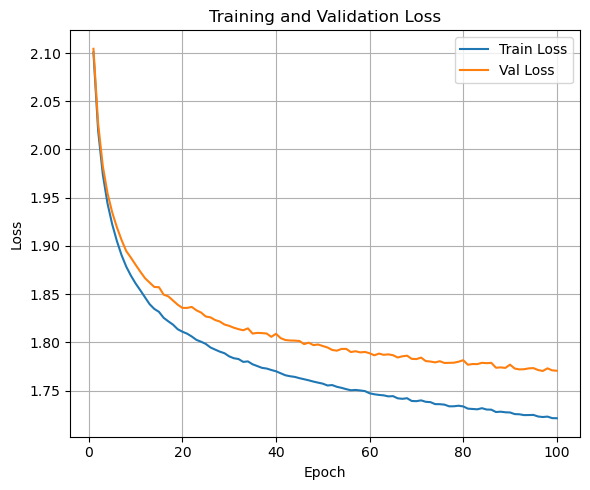

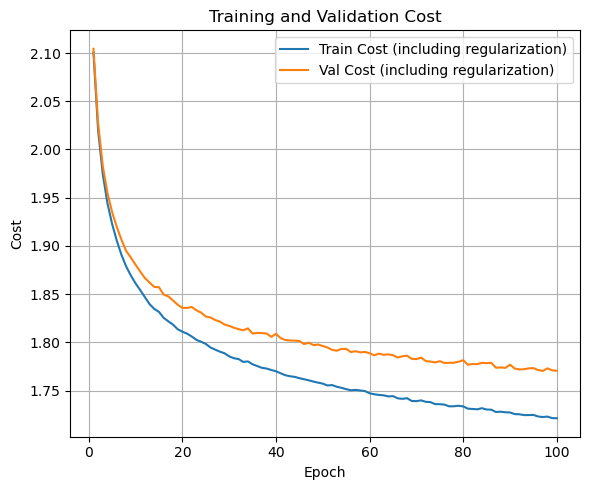

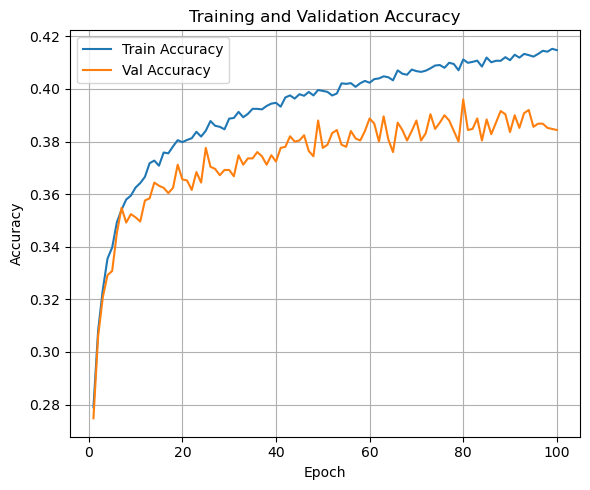

In [36]:
optimizer.plot_training_progress()

In [11]:
# test the model on the test set
X_test, Y_test, y_test = load_batch("test_batch")
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.4034


### Augmenting data by flipping images horizontally

In [3]:
xx = X_test[:,0]
aa = np.int32(np.arange(32)).reshape((32, 1))
bb = np.int32(np.arange(31, -1, -1)).reshape((32, 1))
vv = np.tile(32*aa, (1, 32))
ind_flip = vv.reshape((32*32, 1)) + np.tile(bb, (32, 1))
inds_flip = np.vstack((ind_flip, 1024+ind_flip))
inds_flip = np.vstack((inds_flip, 2048+ind_flip))
xx_flipped = xx[inds_flip.flatten()]

NameError: name 'X_test' is not defined

NameError: name 'xx' is not defined

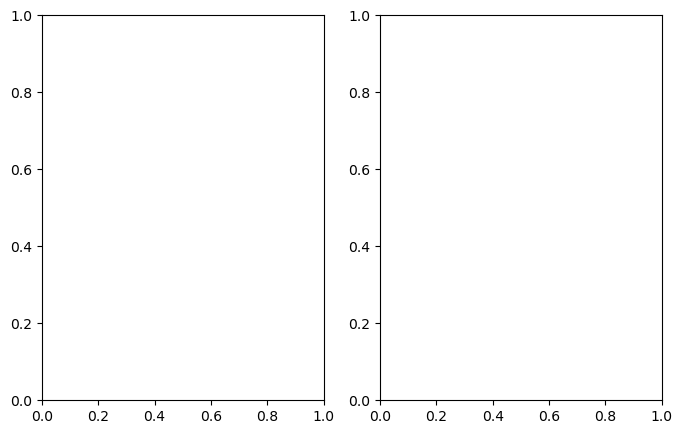

In [4]:
ni = 5
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
xx = xx.reshape((32, 32, 3), order='F')
xx = np.transpose(xx, (1, 0, 2))
axs[0].imshow(xx)
axs[0].axis('off')
xx_flipped = xx_flipped.reshape((32, 32, 3), order='F')
xx_flipped = np.transpose(xx_flipped, (1, 0, 2))
axs[1].imshow(xx_flipped)
axs[1].axis('off')
plt.pause(0.1)

In [5]:
# test the horizontal flipping:
xx = X_train[:,:2]
print(xx.shape)
xx_flipped = optimizer.flip_vertically(xx)
for i in range(2):
    x = xx[:, i]
    print(x.shape)
    x = x.reshape((32, 32, 3), order='F')
    x = np.transpose(x, (1, 0, 2))
    plt.imshow(x)
    plt.axis('off')
    plt.pause(0.1)
for i in range(2):
    x = xx_flipped[:, i]
    print(x.shape)
    x = x.reshape((32, 32, 3), order='F')
    x = np.transpose(x, (1, 0, 2))
    plt.imshow(x)
    plt.axis('off')
    plt.pause(0.1)

(3072, 2)


NameError: name 'optimizer' is not defined

In [16]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.005, reg=0.0, vertical_flip_prob=0.5)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=120, batch_size=100, print_every=10)

Epoch 10/120 - Train Loss: 1.7735, Val Loss: 1.8029, Train Acc: 0.3898, Val Acc: 0.3767
Epoch 20/120 - Train Loss: 1.7351, Val Loss: 1.7706, Train Acc: 0.4065, Val Acc: 0.3980
Epoch 30/120 - Train Loss: 1.7209, Val Loss: 1.7539, Train Acc: 0.4092, Val Acc: 0.3993
Epoch 40/120 - Train Loss: 1.7064, Val Loss: 1.7498, Train Acc: 0.4181, Val Acc: 0.4080
Epoch 50/120 - Train Loss: 1.7072, Val Loss: 1.7588, Train Acc: 0.4172, Val Acc: 0.4020
Epoch 60/120 - Train Loss: 1.6951, Val Loss: 1.7395, Train Acc: 0.4209, Val Acc: 0.4160
Epoch 70/120 - Train Loss: 1.6893, Val Loss: 1.7412, Train Acc: 0.4239, Val Acc: 0.4047
Epoch 80/120 - Train Loss: 1.6900, Val Loss: 1.7407, Train Acc: 0.4246, Val Acc: 0.4107
Epoch 90/120 - Train Loss: 1.6813, Val Loss: 1.7353, Train Acc: 0.4276, Val Acc: 0.4120
Epoch 100/120 - Train Loss: 1.6744, Val Loss: 1.7344, Train Acc: 0.4297, Val Acc: 0.4033
Epoch 110/120 - Train Loss: 1.6792, Val Loss: 1.7358, Train Acc: 0.4256, Val Acc: 0.4187
Epoch 120/120 - Train Loss: 1.

In [13]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=20, batch_size=100, print_every=10)

Epoch 10/20 - Train Loss: 1.7210, Val Loss: 1.7584, Train Acc: 0.4127, Val Acc: 0.4033
Epoch 20/20 - Train Loss: 1.7168, Val Loss: 1.7542, Train Acc: 0.4143, Val Acc: 0.4053


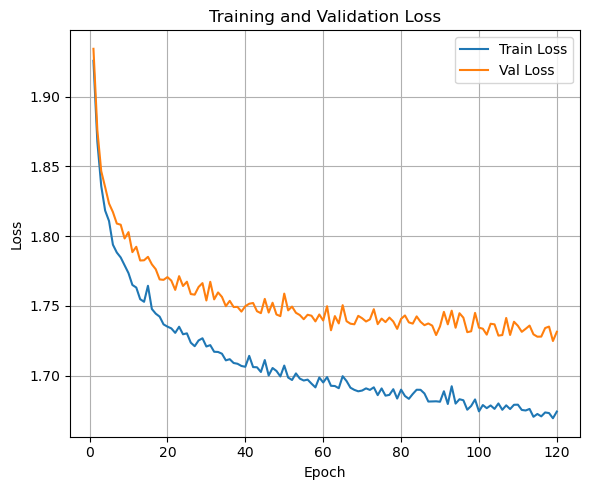

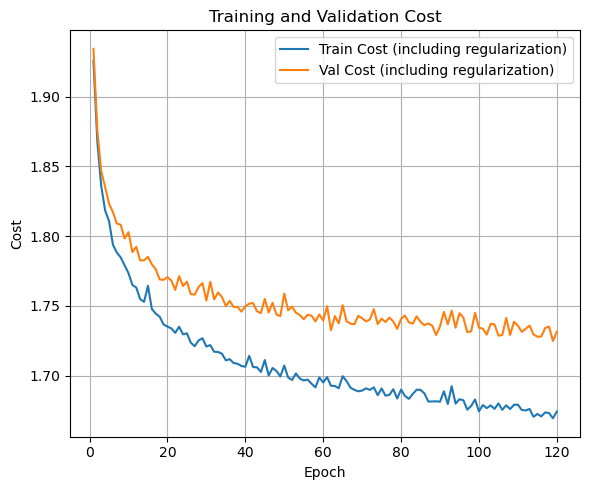

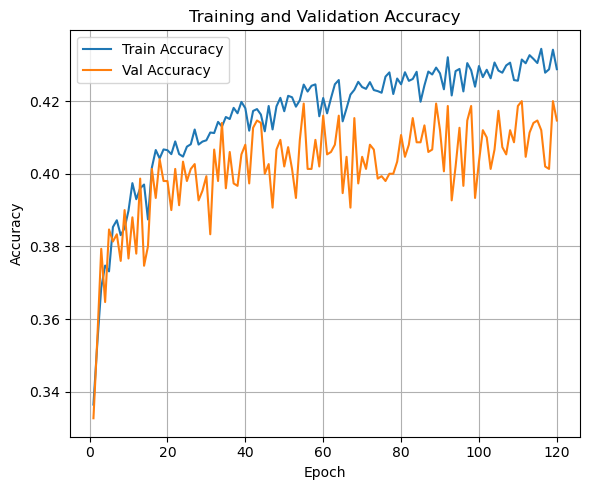

In [17]:
optimizer.plot_training_progress()

In [18]:
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.4123
